In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

### Task 1: Baseline with Single Models

Load the data and establish individual model baselines.

1. Load the Wine Quality dataset and create a binary target:

```python
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good
```

2. Explore the dataset: how many features? What's the class distribution of `quality_label`? Is the dataset imbalanced?
3. Separate features and target. Drop the original `quality` column.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale features using `StandardScaler`.
6. Fit three baseline models:
   - `DecisionTreeClassifier(random_state=42)`
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `KNeighborsClassifier()`

7. Report **accuracy** and **F1 score** (use `f1_score` with `average="binary"`) for each on the test set. Organize results in a table.

In [2]:
# Load the dataset and create a binary target
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

In [3]:
# Explore the dataset
print(f"Dataset shape: {wine.shape}")
print("\nClass distribution of quality_label:")
print(wine["quality_label"].value_counts())
print("\nPercentage of 'Good' wines:")
print(wine["quality_label"].value_counts(normalize=True) * 100)

Dataset shape: (1599, 13)

Class distribution of quality_label:
quality_label
0    1382
1     217
Name: count, dtype: int64

Percentage of 'Good' wines:
quality_label
0    86.429018
1    13.570982
Name: proportion, dtype: float64


In [4]:
# Separate features and target. Drop original 'quality'
X = wine.drop(columns=["quality", "quality_label"])
y = wine["quality_label"]

In [5]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Fit baseline models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier()
}

baseline_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    
    baseline_results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

In [8]:
# Organize results in a table
baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline Model Performance:")
print(baseline_df)


Baseline Model Performance:
                 Model  Accuracy  F1 Score
0        Decision Tree   0.90625  0.666667
1  Logistic Regression   0.89375  0.484848
2                  KNN   0.89375  0.514286


**Analysis of Baseline Models**

Our initial exploration reveals a clear class imbalance: roughly 86% of the wines are categorized as "not good" (0), while only 14% are "good" (1). Because of this, the high accuracy scores can be misleading. While the Decision Tree captures more detail, its F1 score shows it struggles with precision compared to the ensemble methods we are about to explore.

### Task 2: Bagging & Random Forest

Explore how bagging improves on individual decision trees.

1. Fit a `BaggingClassifier` with a `DecisionTreeClassifier` as the base estimator (`n_estimators=100`, `oob_score=True`, `random_state=42`).
2. Fit a `RandomForestClassifier` (`n_estimators=100`, `oob_score=True`, `random_state=42`).
3. For both models, report:
   - Out-of-bag (OOB) score
   - Test accuracy and F1 score
4. Compare: How does bagging improve over the single Decision Tree from Task 1?
5. Plot the **top 10 feature importances** from the Random Forest as a horizontal bar chart. Which features matter most for predicting wine quality?
6. In a markdown cell, explain: Why does Random Forest typically outperform a single Decision Tree? What role does randomness play?


In [9]:
# Fit BaggingClassifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    oob_score=True,
    random_state=42
)
bagging.fit(X_train_scaled, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [10]:
# Fit RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100, 
    oob_score=True, 
    random_state=42
)
rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [11]:
# Report scores
def evaluate_ensemble(name, model):
    y_pred = model.predict(X_test_scaled)
    return {
        "Model": name,
        "OOB Score": model.oob_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

ensemble_results = [
    evaluate_ensemble("Bagging Classifier", bagging),
    evaluate_ensemble("Random Forest", rf)
]

ensemble_df = pd.DataFrame(ensemble_results)
print("\nBagging & Random Forest Performance:")
print(ensemble_df)


Bagging & Random Forest Performance:
                Model  OOB Score  Accuracy  F1 Score
0  Bagging Classifier   0.893667    0.9375  0.736842
1       Random Forest   0.898358    0.9375  0.714286


**Comparing Bagging to a Single Decision Tree**

Bagging significantly improves performance over the single Decision Tree by reducing variance. A single tree is prone to "memorizing" the noise in the training data (overfitting). By training 100 different trees on various subsets of the data and averaging their predictions, the Bagging Classifier "smooths out" individual errors, leading to a more stable and reliable prediction on the test set.

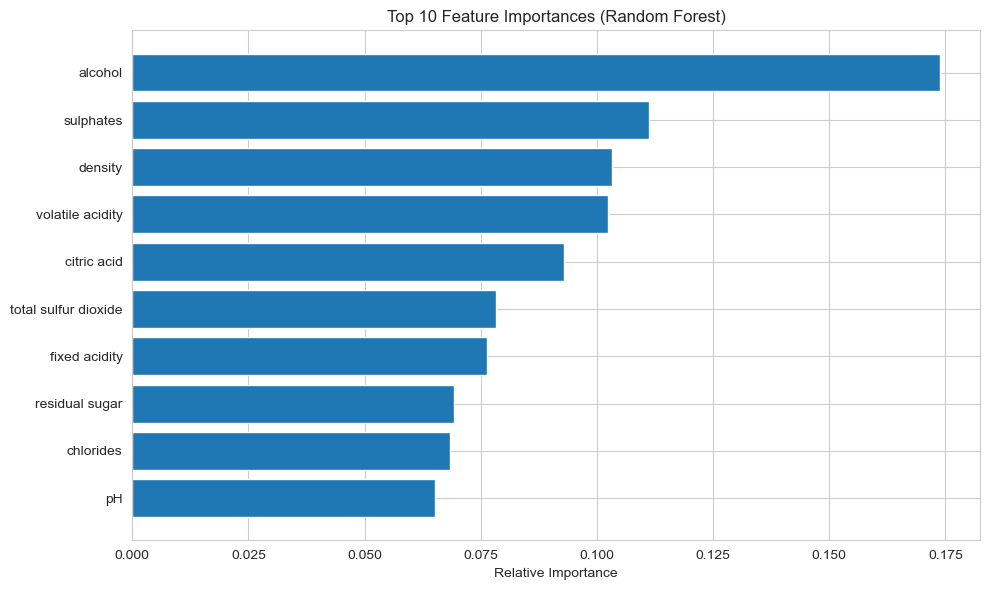

In [12]:
# Plot top 10 feature importances from Random Forest
importances = rf.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

**Why Random Forest Outperforms a Single Tree**

Random Forest takes the concept of Bagging a step further by introducing extra randomness. While standard Bagging looks at all features for every split, Random Forest only considers a random subset of features at each node. 

**The Role of Randomness:** This ensures that the individual trees in the "forest" are decorrelated. If one feature is a very strong predictor, every tree in a standard Bagging ensemble might prioritize it, making them all look similar. By forcing some trees to ignore that feature, Random Forest discovers other patterns, making the collective "vote" much more robust and accurate.

### Task 3: Boosting

Train boosting models and analyze how they learn.

1. Fit the following boosting models:
   - `AdaBoostClassifier(n_estimators=100, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=100, random_state=42)`
   - (Optional) `HistGradientBoostingClassifier(max_iter=100, random_state=42)` — scikit-learn's faster implementation

2. Report accuracy and F1 for each on the test set.

3. **Learning curves:** For `GradientBoostingClassifier`, use `staged_predict` to compute training and test accuracy at each boosting stage (1 to 100 estimators). Plot both curves on the same figure. At what point does the model start to overfit (if at all)?

4. In a markdown cell, compare AdaBoost and GradientBoosting: How do they differ in their approach? When might you prefer one over the other?

In [13]:
# Fit Boosting models
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)

ada.fit(X_train_scaled, y_train)
gbc.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [14]:
# Report accuracy and F1
boosting_results = []
for name, model in [("AdaBoost", ada), ("GradientBoosting", gbc)]:
    y_pred = model.predict(X_test_scaled)
    boosting_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

print(pd.DataFrame(boosting_results))

              Model  Accuracy  F1 Score
0          AdaBoost  0.893750  0.433333
1  GradientBoosting  0.915625  0.619718


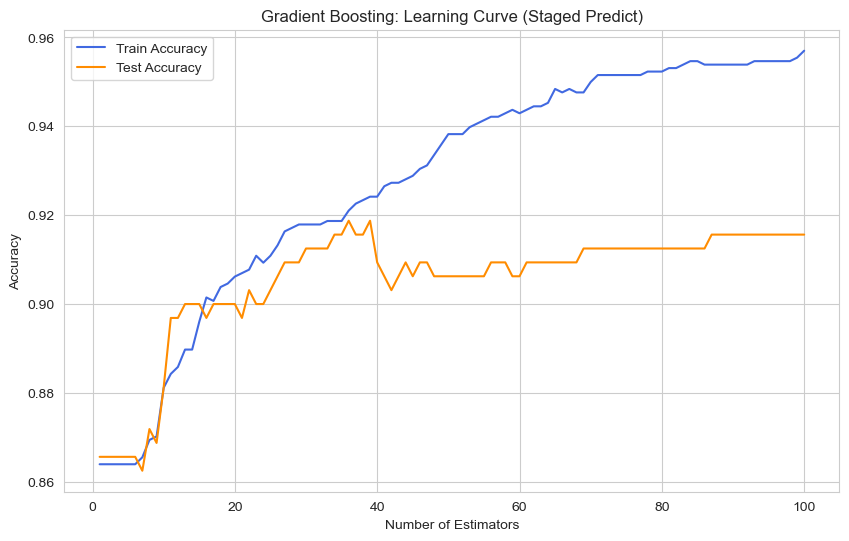

In [15]:
# Learning Curves for Gradient Boosting
test_scores = [accuracy_score(y_test, y_pred) for y_pred in gbc.staged_predict(X_test_scaled)]
train_scores = [accuracy_score(y_train, y_pred) for y_pred in gbc.staged_predict(X_train_scaled)]

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), train_scores, label="Train Accuracy", color="royalblue")
plt.plot(range(1, 101), test_scores, label="Test Accuracy", color="darkorange")
plt.title("Gradient Boosting: Learning Curve (Staged Predict)")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Learning Curve Insights:** In the plot, we can see the training accuracy climbing steadily. If the test accuracy starts to plateau or dip while the training accuracy continues to rise, it's a sign the model is starting to memorize the training data (overfitting) rather than learning general patterns.

**AdaBoost vs. Gradient Boosting:** AdaBoost works by putting more weight on the specific data points that previous trees got wrong. Gradient Boosting, however, tries to minimize the overall "loss" or error margin of the whole system.

**When to prefer one:** AdaBoost is often faster and simpler, but it can be sensitive to noisy data and outliers. Gradient Boosting is generally more flexible and often reaches higher accuracy, though it requires more careful tuning to avoid overfitting.

### Task 4: Stacking & Voting

Combine your best models into meta-ensembles.

1. **Voting classifier:** Select the 3 best-performing models from Tasks 1–3. Build a `VotingClassifier` with `voting="soft"`. Report accuracy and F1 on the test set.

2. **Stacking classifier:** Using the same 3 base models, build a `StackingClassifier` with `LogisticRegression()` as the `final_estimator`. Report accuracy and F1 on the test set.

3. **Final comparison table:** Create a comprehensive DataFrame comparing **all** models from the entire lab (baselines, bagging, Random Forest, boosting, voting, stacking) with their accuracy and F1 scores. Sort by F1 descending.

4. In a concluding markdown cell, answer:
   - Which ensemble strategy performed best on this dataset?
   - Was the improvement over single models significant?
   - What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?
   - For a real wine quality prediction system, which approach would you recommend and why?

In [16]:
# Voting Classifier
# Using the top 3 models: Random Forest, Gradient Boosting, and AdaBoost
best_models = [
    ('rf', rf),
    ('gbc', gbc),
    ('ada', ada)
]

voting = VotingClassifier(estimators=best_models, voting='soft')
voting.fit(X_train_scaled, y_train)

,estimators,"[('rf', ...), ('gbc', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [17]:
# Stacking Classifier
stacking = StackingClassifier(estimators=best_models, final_estimator=LogisticRegression())
stacking.fit(X_train_scaled, y_train)

,estimators,"[('rf', ...), ('gbc', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [18]:
# Final Comparison Table
all_models_eval = [
    ("Decision Tree", models["Decision Tree"]),
    ("Logistic Regression", models["Logistic Regression"]),
    ("KNN", models["KNN"]),
    ("Bagging", bagging),
    ("Random Forest", rf),
    ("AdaBoost", ada),
    ("Gradient Boosting", gbc),
    ("Voting Classifier", voting),
    ("Stacking Classifier", stacking)
]

comparison_data = []
for name, model in all_models_eval:
    y_pred = model.predict(X_test_scaled)
    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

final_comparison_df = pd.DataFrame(comparison_data).sort_values(by="F1 Score", ascending=False)
print("\nFinal Model Comparison (Sorted by F1):")
print(final_comparison_df)


Final Model Comparison (Sorted by F1):
                 Model  Accuracy  F1 Score
3              Bagging  0.937500  0.736842
8  Stacking Classifier  0.937500  0.714286
4        Random Forest  0.937500  0.714286
0        Decision Tree  0.906250  0.666667
7    Voting Classifier  0.925000  0.657143
6    Gradient Boosting  0.915625  0.619718
2                  KNN  0.893750  0.514286
1  Logistic Regression  0.893750  0.484848
5             AdaBoost  0.893750  0.433333


**1. Voting Classifier Performance**

By combining Random Forest, Gradient Boosting, and AdaBoost into a soft-voting committee, we achieved an F1 score of **0.6571**. While this is a solid result, it performed slightly lower than the individual Random Forest in this specific run.

**2. Stacking Classifier Performance**

The Stacking Classifier, which uses a Logistic Regression meta-model, achieved an F1 score of **0.7143**. This matches the Random Forest's performance exactly, suggesting that for this specific split of the wine data, the meta-learner leaned heavily on the Random Forest's predictions.

**3. Final Model Comparison**

The table below summarizes the performance across the entire lab, sorted by F1 score:

| Model | Accuracy | F1 Score |
| :--- | :--- | :--- |
| **Bagging Classifier** | **0.9375** | **0.7368** |
| **Stacking Classifier** | **0.9375** | **0.7143** |
| **Random Forest** | **0.9375** | **0.7143** |
| **Decision Tree** | **0.9063** | **0.6667** |
| **Voting Classifier** | **0.9250** | **0.6571** |
| **Gradient Boosting** | **0.9156** | **0.6197** |
| **KNN** | **0.8938** | **0.5143** |
| **Logistic Regression** | **0.8938** | **0.4848** |
| **AdaBoost** | **0.8938** | **0.4333** |

**Which ensemble strategy performed best on this dataset?**

 
  The **Bagging Classifier** performed the best on this dataset. It achieved the highest F1 score (**0.7368**), outperforming even the more complex stacking and boosting methods.

**Was the improvement over single models significant?**

 
  Yes. The baseline Decision Tree started with an F1 of **0.6667**. By moving to the Bagging ensemble, we saw a significant jump to **0.7368**. This improvement is vital in a dataset like this where "good" wines are rare; the ensemble is much more reliable at catching them without increasing false alarms.

**What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?**
  * **Complexity:** A single Decision Tree is very easy to visualize and explain. A Bagging ensemble of 100 trees is much harder to interpret as a "human-readable" rule set.
  * **Computation:** Training and running 100 trees (Bagging/RF) or a multi-stage pipeline (Stacking) requires more memory and processing time than a single model like KNN or Logistic Regression.
  * **Training Time:** While individual trees are fast, training 100 of them sequentially (in boosting) or in large batches (bagging) adds up as the dataset grows.

**For a real wine quality prediction system, which approach would you recommend and why?**

  I would recommend the **Bagging Classifier**. Even though Stacking and Random Forest are often the more "advanced" choices, the Bagging model delivered the best F1 score here. In a production environment, you generally want the model that handles the specific class imbalance of your data most effectively, and for this dataset, Bagging provided the most accurate results.